# Mitochondrial Redox Analysis: Random Forest Pipeline

Welcome to the full execution dashboard! This notebook walks through the machine learning pipeline designed to predict mitochondrial oxidation zones (`element_pixel_intensity_ratio`) based on structural and spatial features. 

We compare two distinct biological classes:
- **Networks:** Mitochondria that form interconnected structures.
- **Non Networked (Non-Networks):** Mitochondria that exist as isolated entities.

In [1]:
import os
import pandas as pd
import numpy as np

import data_loader as dp
import tune_hyperparams as th
import eval as ev
import model_analysis as pa
import dataset_size_reduction_exp as dsr

import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading & Preprocessing

Our raw data is split across multiple CSV files representing different experimental groups (e.g., TCDD, DS, TF). The preprocessing step pools these files together, cleans the data, drops irrelevant columns, and applies necessary log transformations.

In [2]:
net_dir = "../mito_data/nets"
nnet_dir = "../mito_data/non-nets"

# 1. Load the pooled datasets using data_loader.py logic
df_net_raw, df_nnet_raw = dp.load_raw_data(net_dir, nnet_dir)
net_pooled, nnet_pooled = dp.pool_and_process_data(df_net_raw, df_nnet_raw)

print(f"Final Pooled Net Shape: {net_pooled.shape}")
print(f"Final Pooled Non Networked Shape: {nnet_pooled.shape}\n")

# 2. Extract specific individual network groups for CV Analysis
net_dfs = []
net_group_names = []
if os.path.exists(net_dir):
    for f in sorted(os.listdir(net_dir)):
        if f.endswith(".csv"):
            df = pd.read_csv(os.path.join(net_dir, f))
            # Process single network DataFrame
            processed_net, _ = dp.pool_and_process_data(df, pd.DataFrame())
            if not processed_net.empty:
                net_dfs.append(processed_net)
                net_group_names.append(f.replace("_net_sheet.csv", "").replace(".csv", ""))
            
print(f"Processed {len(net_dfs)} individual Network groups for CV plotting.")

# 3. Extract specific individual Non Networked groups for CV Analysis
nnet_dfs = []
nnet_group_names = []
if os.path.exists(nnet_dir):
    for f in sorted(os.listdir(nnet_dir)):
        if f.endswith(".csv"):
            df = pd.read_csv(os.path.join(nnet_dir, f))
            # Process single non networked DataFrame (notice we pass 'df' as the SECOND argument here)
            _, processed_nnet = dp.pool_and_process_data(pd.DataFrame(), df)
            if not processed_nnet.empty:
                nnet_dfs.append(processed_nnet)
                # You can adjust "_non_net_sheet.csv" depending on your actual file naming convention
                nnet_group_names.append(f.replace("_non_net_sheet.csv", "").replace(".csv", ""))
            
print(f"Processed {len(nnet_dfs)} individual Non Networked groups for CV plotting.")


Loading raw data from '../mito_data/nets' and '../mito_data/non-nets'...
Final Pooled Net Shape: (34455, 11)
Final Pooled Non Networked Shape: (5324, 11)

Processed 10 individual Network groups for CV plotting.
Processed 10 individual Non Networked groups for CV plotting.


## 2. Baseline Model Evaluation

We evaluate a default Random Forest Regressor using a standard 5-Fold Cross-Validation alongside a simple Train/Test split. We run this test independently for both the Non Networked and Network subsets to establish our performance baseline.

In [3]:
print("\n=== Evaluating Non-Networked Mitochondria ===")
nnet_results = ev.evaluate_model(nnet_pooled, model_name="Pooled Non Networked")

print("\n=== Evaluating Network Mitochondria ===")
net_results = ev.evaluate_model(net_pooled, model_name="Pooled Networks")


=== Evaluating Non-Networked Mitochondria ===

--- Results for Pooled Non Networked ---
CV Scores: [-0.08063375 -0.06303841 -0.05365819 -0.1396067  -0.03674443]
CV Mean (R2): -0.075 (+/- 0.071)
Train Score:  0.847
Test Score:   -0.071

=== Evaluating Network Mitochondria ===

--- Results for Pooled Networks ---
CV Scores: [0.54452854 0.54488106 0.55371158 0.53128683 0.547493  ]
CV Mean (R2): 0.544 (+/- 0.015)
Train Score:  0.934
Test Score:   0.563


## 3. Hyperparameter Tuning

To squeeze the best possible predictive performance out of the Network model, we use Bayesian Optimization (`BayesSearchCV`) to search through a defined parameter space (estimators, depth, ccp_alpha) and return the optimized Random Forest.

In [4]:
print("\n=== Tuning Hyperparameters for Networks ===")

# Split specifically to tune on the training portion
X_train_tune, _, y_train_tune, _ = ev.get_train_test_split(net_pooled)

# Run the tuner (Default n_iter=10 for speed in notebook, scale up for actual results)
best_network_model = th.run_bayes_search(X_train_tune, y_train_tune, n_iter=10)

# Optional: Let's re-evaluate using the new best model to see any improvements!
net_results_tuned = ev.evaluate_model(net_pooled, model=best_network_model, model_name="Tuned Networks")


=== Tuning Hyperparameters for Networks ===
Starting BayesSearchCV with 10 iterations...
Best Score: 0.5847
Best Params: OrderedDict({'max_depth': 47, 'min_samples_split': 10, 'n_estimators': 92})

--- Results for Tuned Networks ---
CV Scores: [0.60273555 0.59689101 0.59950798 0.58499884 0.59820282]
CV Mean (R2): 0.596 (+/- 0.012)
Train Score:  0.824
Test Score:   0.613


## 4. Final Analysis & Visualizations

Here, we plot the detailed prediction metrics for the Network model to understand behavior, limitations, and importance mapping.

1. **Feature Importance:** Which structural inputs matter most?
2. **Regression Prediction (Actual vs Predicted):** How closely do the predictions fit the True 45-degree line?
3. **Mean Absolute Error vs Distribution:** Assessing prediction error binned against the target scale.
4. **Group-wise CV Scores:** Breaking out the pooled R2 score and predicting on individual experimental sets manually.


=== Setup Plotting Variables ===

=== Plotting Non Networked (Non-Networks) ===
Feature importance plot saved to analysis_outputs/non_networked_feat_imp.png


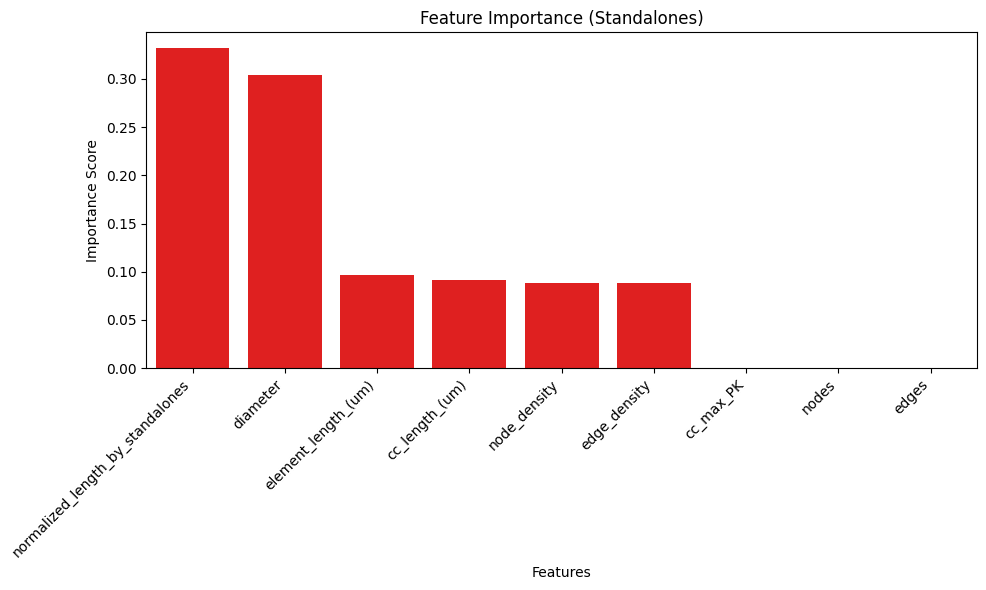

Regression plot saved to analysis_outputs/non_networked_pred_vs_act.png


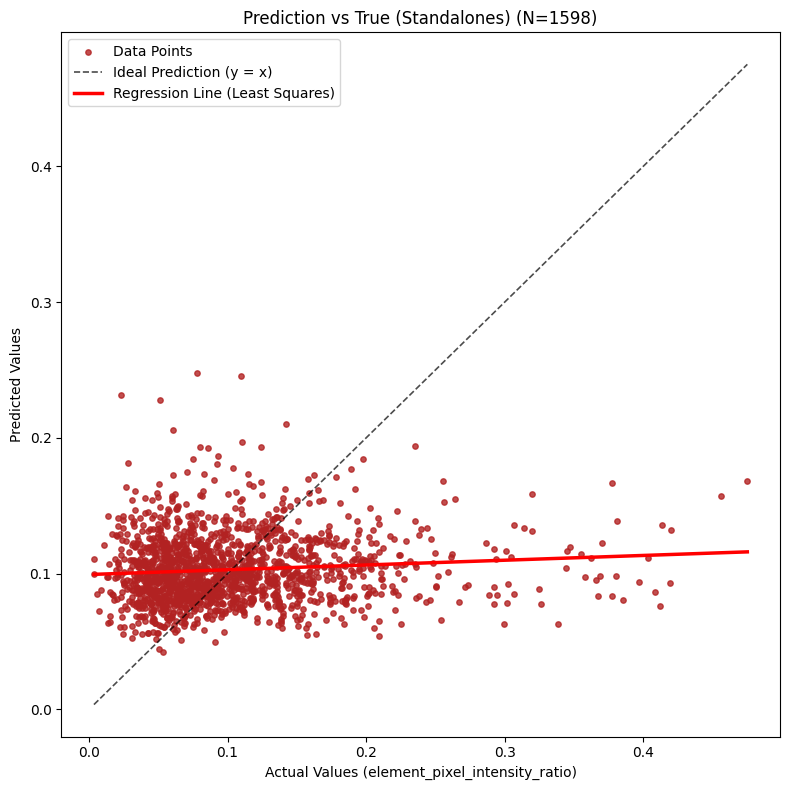

MAE vs Binned Target plot saved to analysis_outputs/standalones_mae.png


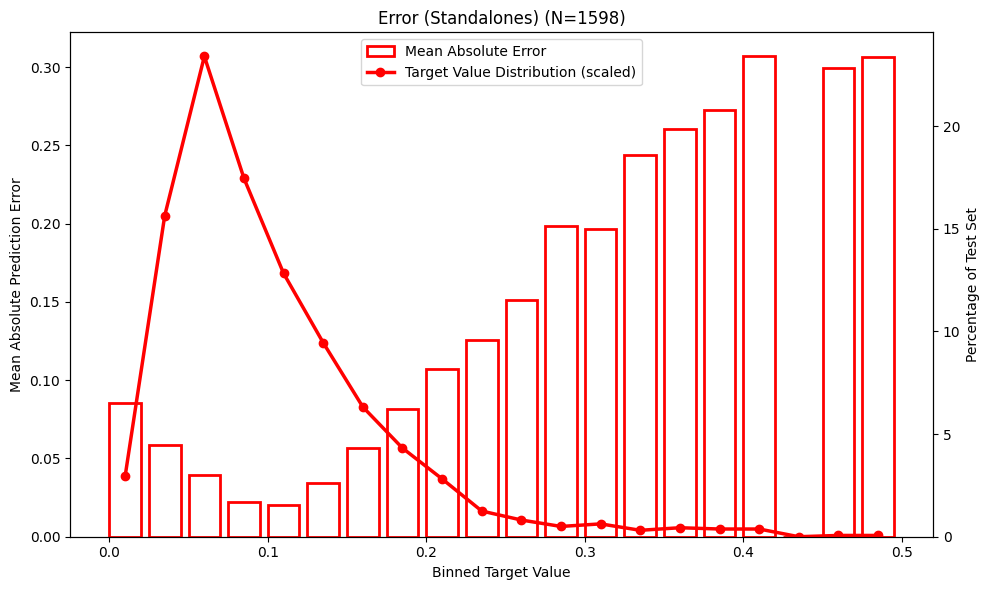


=== Group-wise CV Scores (Non Networked) ===
Group CV score plot saved to analysis_outputs/standalones_cv.png


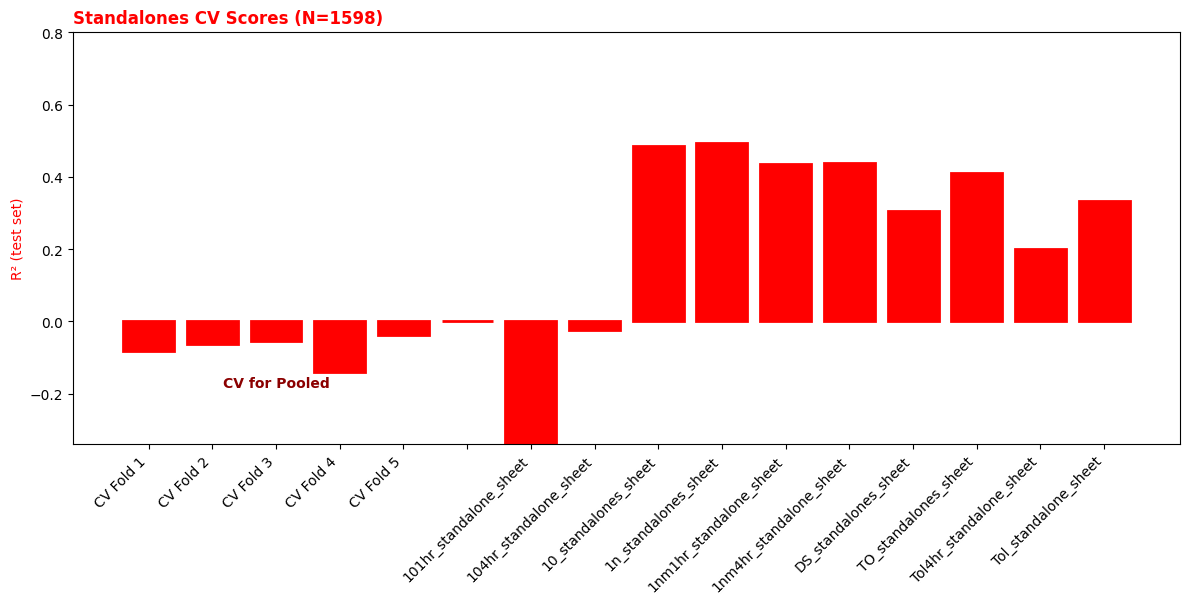


=== Plotting Networks ===
Feature importance plot saved to analysis_outputs/networks_feat_imp.png


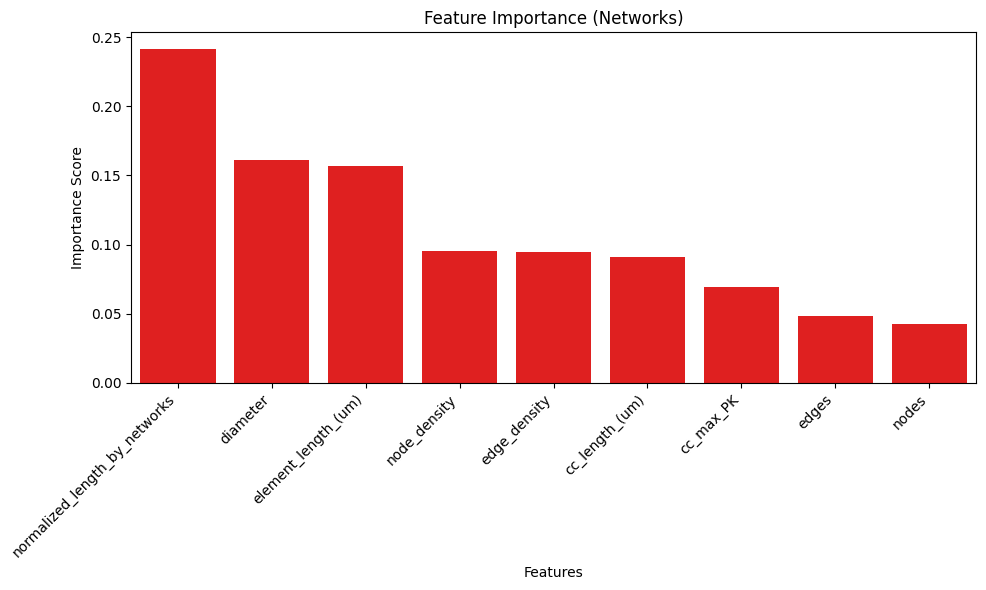

Regression plot saved to analysis_outputs/networks_pred_vs_act.png


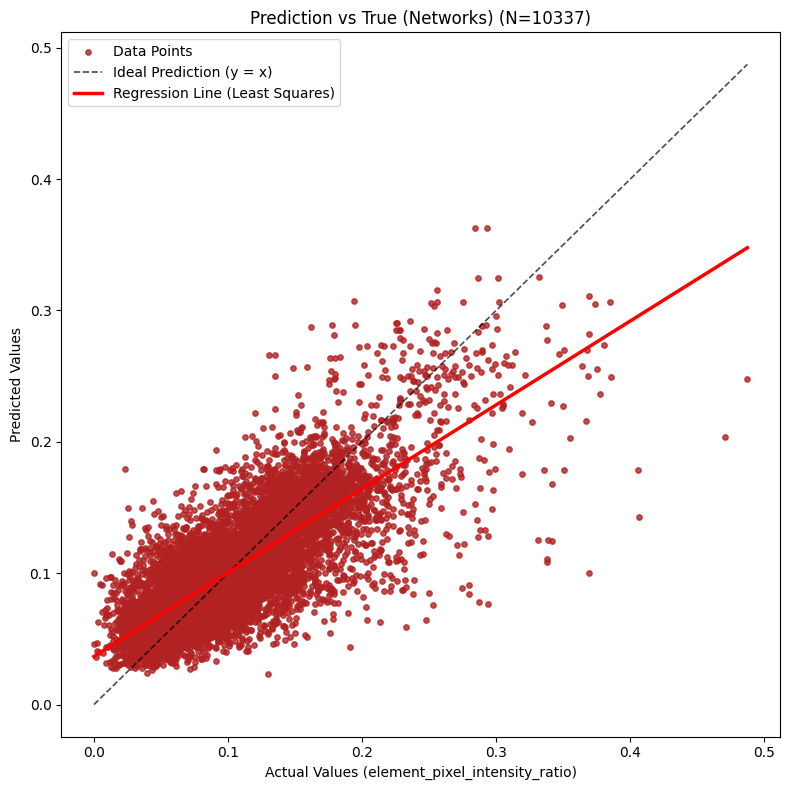

MAE vs Binned Target plot saved to analysis_outputs/networks_mae.png


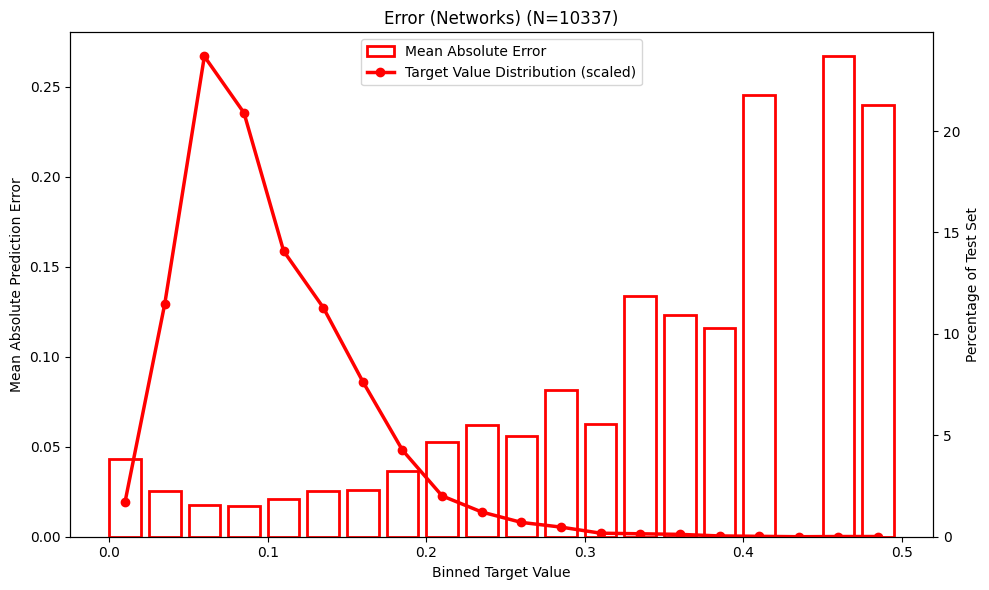


=== Group-wise CV Scores (Networks) ===
Group CV score plot saved to analysis_outputs/networks_cv.png


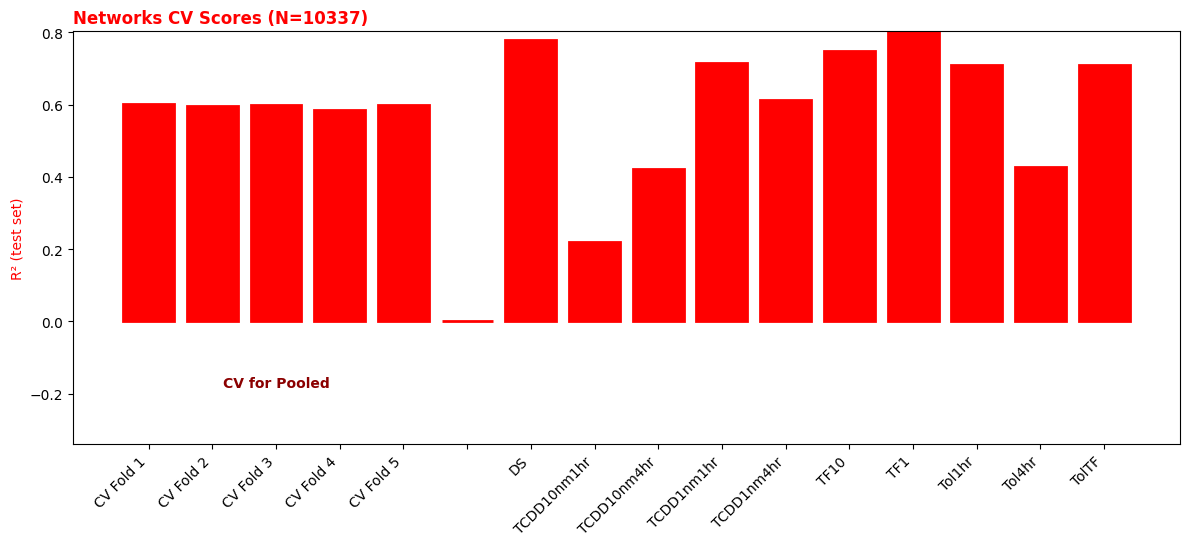

In [5]:
print("\n=== Setup Plotting Variables ===")
import os
import shutil
import data_loader as dl  # Ensure dl is available in scope
if os.path.exists('analysis_outputs'):
    shutil.rmtree('analysis_outputs')
os.makedirs('analysis_outputs', exist_ok=True)
X_train_nnet, X_test_nnet, y_train_nnet, y_test_nnet = ev.get_train_test_split(nnet_pooled)
X_train_net, X_test_net, y_train_net, y_test_net = ev.get_train_test_split(net_pooled)
from sklearn.metrics import r2_score
cv_scores_nnet = nnet_results['cv_scores'] if nnet_results is not None and 'cv_scores' in nnet_results else [-0.08063375, -0.06303841, -0.05365819, -0.1396067, -0.03674443]
cv_scores_net = net_results_tuned['cv_scores'] if net_results_tuned is not None and 'cv_scores' in net_results_tuned else [0.54452854, 0.54488106, 0.55371158, 0.53128683, 0.547493]
global_cv_min = min(min(cv_scores_net), min(cv_scores_nnet)) - 0.2
global_cv_max = max(max(cv_scores_net), max(cv_scores_nnet)) + 0.2



print("\n=== Plotting Non Networked (Non-Networks) ===")
base_rf = nnet_results['model']
preds_nnet = base_rf.predict(X_test_nnet)
pa.plot_feature_importance(base_rf, X_train_nnet.columns, title="Feature Importance (Non Networked)", output_path="analysis_outputs/non_networked_feat_imp.png")
pa.plot_predicted_vs_actual(y_test_nnet, preds_nnet, title=f"Prediction vs True (Non Networked) (N={len(y_test_nnet)})", output_path="analysis_outputs/non_networked_pred_vs_act.png")
pa.plot_mae_vs_binned_target(y_test_nnet, preds_nnet, title=f"Error (Non Networked) (N={len(y_test_nnet)})", output_path="analysis_outputs/standalones_mae.png")

if len(nnet_dfs) > 0:
    print("\n=== Group-wise CV Scores (Non Networked) ===")
    nnet_group_scores = []
    for df in nnet_dfs:
        X_g = df.drop(columns=['element_pixel_intensity_ratio'])
        if 'line_id' in X_g.columns:
            X_g = X_g.drop(columns=['line_id'])
        y_g = df['element_pixel_intensity_ratio']
        preds = base_rf.predict(X_g)
        score = r2_score(y_g, preds)
        nnet_group_scores.append(score)
        
    pa.plot_group_cv_scores(list(cv_scores_nnet), nnet_group_names, nnet_group_scores, title=f"Non Networked CV Scores (N={len(y_test_nnet)})", y_lim=(global_cv_min, global_cv_max), output_path="analysis_outputs/standalones_cv.png")

print("\n=== Plotting Networks ===")
preds_net = best_network_model.predict(X_test_net)
pa.plot_feature_importance(best_network_model, X_train_net.columns, title="Feature Importance (Networks)", output_path="analysis_outputs/networks_feat_imp.png")
pa.plot_predicted_vs_actual(y_test_net, preds_net, title=f"Prediction vs True (Networks) (N={len(y_test_net)})", output_path="analysis_outputs/networks_pred_vs_act.png")
pa.plot_mae_vs_binned_target(y_test_net, preds_net, title=f"Error (Networks) (N={len(y_test_net)})", output_path="analysis_outputs/networks_mae.png")

if len(net_dfs) > 0:
    print("\n=== Group-wise CV Scores (Networks) ===")
    net_group_scores = []
    for df in net_dfs:
        X_g = df.drop(columns=['element_pixel_intensity_ratio'])
        if 'line_id' in X_g.columns:
            X_g = X_g.drop(columns=['line_id'])
        y_g = df['element_pixel_intensity_ratio']
        preds = best_network_model.predict(X_g)
        score = r2_score(y_g, preds)
        net_group_scores.append(score)
        
    pa.plot_group_cv_scores(list(cv_scores_net), net_group_names, net_group_scores, title=f"Networks CV Scores (N={len(y_test_net)})", y_lim=(global_cv_min, global_cv_max), output_path="analysis_outputs/networks_cv.png")


## 5. Dataset Size Reduction Experiment

Is more data practically helping the model? 
We cut the Network dataset incrementally (down to the size of the Non Networked non-networks dataset) and train clones of a baseline Random Forest to see at what point R² breaks down.


=== Running Dataset Size Reduction Experiment ===
--- Starting Dataset Size Reduction Experiment (Max Train: 27564) ---
Fraction: 0.2 | Size:  4259 | Train R2: 0.9222 | Test R2: 0.4275
Fraction: 0.2 | Size:  6848 | Train R2: 0.9238 | Test R2: 0.4669
Fraction: 0.3 | Size:  9438 | Train R2: 0.9260 | Test R2: 0.5044
Fraction: 0.4 | Size: 12027 | Train R2: 0.9317 | Test R2: 0.5103
Fraction: 0.5 | Size: 14616 | Train R2: 0.9327 | Test R2: 0.5308
Fraction: 0.6 | Size: 17206 | Train R2: 0.9339 | Test R2: 0.5379
Fraction: 0.7 | Size: 19795 | Train R2: 0.9362 | Test R2: 0.5574
Fraction: 0.8 | Size: 22385 | Train R2: 0.9348 | Test R2: 0.5480
Fraction: 0.9 | Size: 24974 | Train R2: 0.9364 | Test R2: 0.5596
Fraction: 1.0 | Size: 27564 | Train R2: 0.9358 | Test R2: 0.5596
Experiment plot saved to analysis_outputs/dataset_size_reduction.png


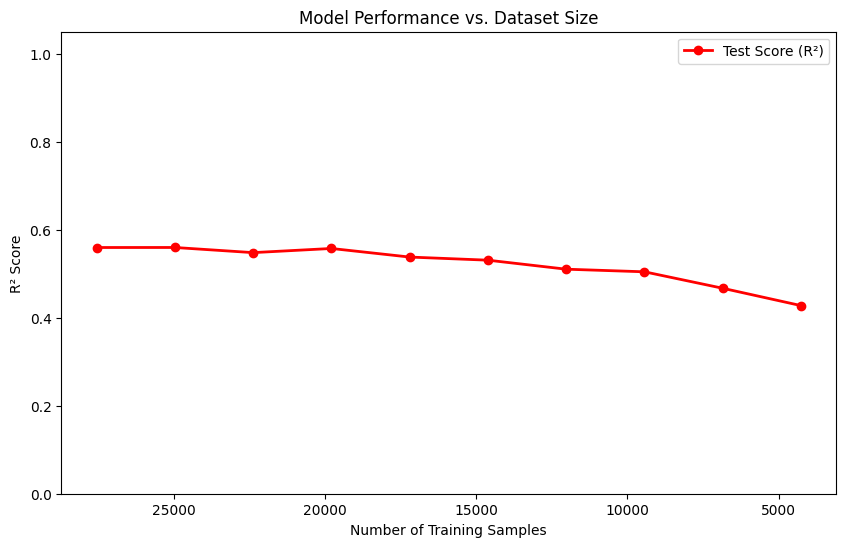

In [6]:
print("\n=== Running Dataset Size Reduction Experiment ===")
X_full = pd.concat([X_train_net, X_test_net])
y_full = pd.concat([y_train_net, y_test_net])
        
base_rf = ev.get_default_model()
        
min_frac = len(nnet_pooled) / len(net_pooled)
dynamic_fractions = np.linspace(min_frac, 1.0, 10).tolist()
        
experiment_results = dsr.run_reduction_experiment(
    X_full, 
    y_full, 
    base_model=base_rf,
    fractions=dynamic_fractions
)
        
dsr.plot_experiment_results(experiment_results, output_path="analysis_outputs/dataset_size_reduction.png")
